# Laboratorio 4

## Integrantes

| Nombre                            | Carnet | Usuario Git |
| --------------------------------- | ------ | ----------- |
| Edwin Jose Gabriel De Leon Garcia | 22809  | EJGDLG      |
| Gustavo Adolfo Cruz Bardales      | 22779  | G2309       |
| Josué Emanuel Say Garcia          | 22801  | JosueSay    |
| Mathew Alexander Cordero Aquino   | 22982  | donmatthiuz |


## Repositorio

[Link al Repositorio](https://github.com/donmatthiuz/RL/tree/lab4)

## Caso

Una empresa de logística de última milla está evaluando el uso de robots autónomos para la gestión interna de su almacén principal. El almacén se modela como una cuadrícula de 8x8 con puntos de recogida, puntos de entrega, zonas de penalización por congestión, y obstáculos fijos. El equipo de ingeniería necesita comparar dos estrategias de aprendizaje antes de comprometer recursos en un sistema completo: una política conservadora que aprenda a navegar de forma segura durante el entrenamiento, y una política agresiva que busque la ruta óptima sin importar los riesgos durante la exploración.

Su grupo ha sido contratado para implementar ambas estrategias usando SARSA y Q-Learning respectivamente, comparar su comportamiento empírico, y producir un dictamen técnico con recomendaciones concretas para la gerencia.

## Task 1

Diseñen formalmente el MDP que representa el almacén. El diseño debe especificar:

### Inciso 1

El espacio de estados y el espacio de acciones. Justifiquen cada decisión considerando la interfaz de Gymnasium: `observation_space` y `action_space` deben ser instancias de `gymnasium.spaces.Discrete` o `gymnasium.spaces.Box` según corresponda. Argumenten cuál es más apropiado para este dominio.

**Respuestas:**

**Espacio de estados $\mathcal{S}$:**

El almacén es una cuadrícula de $8\times8$. El estado debe representar la posición actual del robot y si lleva o no un paquete:

$
s=(fila,columna,carga)
$

donde $fila,columna\in{0,\ldots,7}$ y $carga\in{0,1}$.

Se utilizará `gymnasium.spaces.Discrete(128)`, ya que existen:

$
8\times8\times2=128
$

combinaciones posibles porque el entorno tiene un número finito y discreto de estados, en caso de ser variables continuas se usaría box.

**Espacio de acciones $\mathcal{A}$:**

$
\mathcal{A}={\text{arriba},\text{abajo},\text{izquierda},\text{derecha}}
$

Se utilizará:

```python
action_space = gymnasium.spaces.Discrete(4)
```

Cada valor representa una dirección, por ejemplo:

$
0=\uparrow,\quad1=\rightarrow,\quad2=\downarrow,\quad3=\leftarrow
$

`Discrete(4)` porque el robot tiene 4 acciones.

### Inciso 2

La función de recompensa con al menos tres componentes: recompensa por entrega exitosa, penalización por zona de congestión, y penalización por paso. Justifiquen la magnitud relativa de cada componente y argumenten qué comportamiento indeseable produciría una ponderación incorrecta de alguno de ellos.

**Respuestas:**

Se propone la siguiente función de recompensa:

$$
r(s,a,s')=
\begin{cases}
+100 & \text{si realiza una entrega exitosa}\
-10 & \text{si entra en una zona de congestión}\
-1 & \text{por cada paso realizado}
\end{cases}
$$

Una entrega recibe la mayor recompensa porque representa el objetivo principal ($+100$). La congestión tiene una penalización mayor que un paso normal $(-10)$ para incentivar rutas seguras, mientras que cada paso cuesta $-1$ para favorecer rutas cortas.

Una ponderación incorrecta se observaría en penalización de congestión demasiado pequeña haría que el robot la ignore, mientras que una penalización excesiva podría provocar rutas innecesariamente largas. Si el costo por paso fuera demasiado alto, el agente podría preferir atravesar zonas riesgosas únicamente para reducir la distancia.

### Inciso 3

La condición de terminación del episodio. ¿Cuándo termina un episodio? ¿Es apropiado tener un límite máximo de pasos? Justifiquen.

**Respuestas:**

El episodio termina cuando el robot completa la entrega en el punto.

Sí es adecuado colocar un límite de pasos como $T_{\max}=200$

porque si el robot alcanza los $200$ pasos sin completar la entrega puede indicar que esta truncado. Este límite es apropiado porque evita episodios largos causados por exploración, ciclos. Además, permite mantener un costo computacional controlado durante el entrenamiento. En Gymnasium, la entrega corresponde a `terminated=True`, mientras que alcanzar el límite de pasos corresponde a `truncated=True`.

### Inciso 4

El diseño del mapa $8 \times 8$: ubiquen al menos dos zonas de congestión adyacentes a rutas de alta recompensa. Esta configuración específica es crítica para que la comparación entre SARSA y Q-Learning sea informativa. Expliquen por qué esa configuración espacial genera el comportamiento diferencial esperado entre ambos algoritmos.

**Respuestas:**

```text
- - - - - - - -
- R - - - - - -
- - # # - - - -
- - - - - - - -
- - - C C C E -
- - - - - - - -
- - # # - - - -
- - - - - - - -
```

Donde:

* `R` = punto de recogida.
* `E` = punto de entrega.
* `C` = zona de congestión.
* `#` = obstáculo.
* `-` = espacio libre.

La ubicación de congestión cerca de una ruta atractiva genera dos alternativas:

- Ruta corta pero riesgosa.
- Ruta más larga pero segura.

**SARSA**, al ser *on-policy*, aprende considerando las acciones exploratorias que realmente ejecuta, por lo que tiende a valorar más las rutas seguras. **Q-Learning**, al ser *off-policy*, actualiza utilizando la mejor acción futura:

$$
\max_{a'}Q(s',a')
$$

por lo que tiende a aprender la ruta óptima más corta aunque esté próxima a zonas penalizadas.

## Task 2

Antes de implementar nada, respondan las siguientes preguntas con argumentación técnica:

### Inciso 1

Para el entorno que diseñaron, predigan formalmente cuál algoritmo, SARSA o Q-Learning, produciría mayor recompensa acumulada durante el entrenamiento y cuál producirá mayor recompensa durante la evaluación con política greedy pura. Justifiquen cada predicción usando las propiedades on-policy y off-policy de cada algoritmo y la estructura específica de su mapa.

**Respuesta:**

SARSA debería obtener una mayor recompensa acumulada porque es *on-policy* y actualiza considerando la acción $a'$ que realmente ejecutará:

$$
Q(s,a)\leftarrow Q(s,a)+\alpha[r+\gamma Q(s',a')-Q(s,a)]
$$

Como la política $\epsilon$-greedy puede cometer acciones exploratorias y SARSA aprende el riesgo asociado a transitar cerca de las zonas de congestión y tiende a elegir la ruta más segura reduciendo penalizaciones en el entrenamiento

Q-Learning al ser *off-policy*, actualiza suponiendo que en el siguiente estado tomará la mejor acción:

$$
Q(s,a)\leftarrow Q(s,a)+\alpha[r+\gamma\max_{a'}Q(s',a')-Q(s,a)]
$$

Por ello puede aprender una ruta más corta cercana a la congestión, aunque durante la exploración tenga más penalizaciones.

Durante la **evaluación con política greedy pura** $(\epsilon=0)$, se espera que Q-Learning obtenga mayor recompensa porque ya no existe el riesgo de acciones exploratorias y puede explotar directamente la ruta óptima aprendida. SARSA puede conservar una ruta más segura pero más larga, acumulando más penalizaciones de $-1$ por paso.

### Inciso 2

Argumenten cómo afecta el valor de $\epsilon$ al comportamiento diferencial entre SARSA y Q-Learning en su entorno. ¿Existe un valor de $\epsilon$ para el cual ambos algoritmos convergen a políticas idénticas? Justifiquen matemáticamente.

**Respuesta:**

En una política $\epsilon$-greedy, con $|\mathcal A|=4$:

$$
P(a^*|s)=1-\epsilon+\frac{\epsilon}{4}
$$

y para cada acción no greedy:

$$
P(a|s)=\frac{\epsilon}{4}
$$

Cuando $\epsilon$ es alto, hay mayor exploración. Esto aumenta la diferencia entre los algoritmos. SARSA incorpora indirectamente ese riesgo exploratorio en sus actualizaciones, mientras que Q-Learning continúa actualizando respecto a $\max_{a'}Q(s',a')$.

Cuando:

$$
\epsilon\rightarrow0
$$

la política de comportamiento de SARSA se aproxima a una política greedy:

$$
Q(s',a')\rightarrow\max_{a'}Q(s',a')
$$

Con $\epsilon=0$ y con condiciones de convergencia adecuados tanto SARSA y Q-Learning pueden converger a la misma política óptima. Porque durante el aprendizaje normalmente se utiliza un $\epsilon>0$ porque se quiere garantizar suficiente exploración.

### Inciso 3

Para su función de recompensa específica, calculen una cota superior del valor óptimo $V^*(s_0)$ del estado inicial, asumiendo que el agente siempre toma la ruta más corta sin pasar por zonas de congestión. Usen esta cota como referencia para evaluar qué tan cerca llegan sus implementaciones al óptimo teórico.

**Respuesta:**

Función de recompensa:

* Entrega exitosa: $+100$.
* Paso normal: $-1$.
* Congestión: $-10$.
* Factor de descuento: $\gamma=0.95$.

Si la ruta segura más corta desde $s_0$ hasta la entrega requiere $d$ movimientos y no atraviesa ninguna congestión, la cota de referencia es:

$$
V^*(s_0)\leq
-\sum_{t=0}^{d-2}\gamma^t
+100\gamma^{d-1}
$$

Usando la suma geométrica:

$$
V^*(s_0)\leq
-\frac{1-\gamma^{d-1}}{1-\gamma}
+100\gamma^{d-1}
$$

Sustituyendo $\gamma=0.95$:

$$
\boxed{
V^*(s_0)\leq
-\frac{1-0.95^{d-1}}{0.05}
+100(0.95)^{d-1}
}
$$

Cuanto más cercano sea el retorno obtenido por SARSA o Q-Learning a este valor, más próxima estará su política al óptimo teórico.


## Task 3


Implementen el entorno y los algoritmos con las siguientes especificaciones:

El entorno debe implementarse como una clase `WarehouseEnv` que herede de `gymnasium.Env`, con los métodos `reset`, `step` y `render` correctamente implementados según la interfaz estándar de Gymnasium. El método `render` debe producir una visualización en consola o matplotlib del estado actual del agente en el mapa.

Los algoritmos SARSA y Q-Learning deben implementarse desde cero como funciones o clases separadas que reciban el entorno como argumento y devuelvan la tabla Q aprendida y el historial de recompensas por episodio. No se permite usar implementaciones preconstruidas de SARSA o Q-Learning de ninguna librería.

La implementación debe registrar para cada episodio: la recompensa total acumulada, el número de pasos hasta terminación, y el número de veces que el agente pasó por zonas de congestión. Estos registros son necesarios para el análisis de la Tarea 4.

Al finalizar el entrenamiento, evalúen cada política aprendida con 100 episodios usando política greedy pura, sin exploración, y registren las mismas métricas.

### Resultados 

In [1]:

from src.td_control import evaluate_greedy, train_q_learning, train_sarsa
from src.warehouse_env import WarehouseEnv
from src.run_task3 import print_result

config = dict(episodes=5_000, alpha=0.1, gamma=0.95, epsilon=1.0,
                epsilon_decay=0.995, epsilon_min=0.05, seed=42)

sarsa_q, sarsa_history = train_sarsa(WarehouseEnv(), **config)
q_learning_q, q_learning_history = train_q_learning(WarehouseEnv(), **config)
sarsa_result = evaluate_greedy(WarehouseEnv(), sarsa_q, seed=1_000)
q_learning_result = evaluate_greedy(WarehouseEnv(), q_learning_q, seed=1_000)

print_result("SARSA", sarsa_result)
print_result("Q-Learning", q_learning_result)
print(f"Métricas de entrenamiento registradas: {len(sarsa_history.rewards)} episodios SARSA y "
        f"{len(q_learning_history.rewards)} episodios Q-Learning.")


SARSA (evaluación greedy, 100 episodios)
  recompensa promedio: 89.00
  pasos promedio: 11.00
  visitas promedio a congestión: 0.00
  tasa de éxito: 100.0%
Q-Learning (evaluación greedy, 100 episodios)
  recompensa promedio: 89.00
  pasos promedio: 11.00
  visitas promedio a congestión: 0.00
  tasa de éxito: 100.0%
Métricas de entrenamiento registradas: 5000 episodios SARSA y 5000 episodios Q-Learning.


En la evaluacion greddy SARASA Y Q learning alcanzaron una tasa del 100% una recompensa promedio de 89 y 11 pasos promedio.

Esto quiere decir que ambos algoritmos aprendieron la politica mas optima. 

Aun asi los resultados no confirman que Qlearning elegira uan ruta mas corta. Esto pasa por el mapa porque ya tiene una ruta minima que evita zonas de congestion por lo que no se puede contrastar rapides y seguridad.

Por eso una vez aprendida esta ruta el 100 de los episodios reproducen lo mismo.

## Task 4

Con base en lo aprendido, responda:

### Inciso 1

**Verificación de predicciones:** contrasten cada predicción de la Tarea 2 con los resultados observados. Para cada predicción indiquen si fue confirmada, refutada o inconclusa, y expliquen la discrepancia si la hay. Una predicción refutada con buena explicación vale más que una confirmada sin análisis.

In [2]:
import numpy as np

# Evidencia empírica para contrastar las predicciones de la Tarea 2.
sarsa_rewards = np.array(sarsa_history.rewards)
q_rewards = np.array(q_learning_history.rewards)
sarsa_cong = np.array(sarsa_history.congestion_visits)
q_cong = np.array(q_learning_history.congestion_visits)
window = 500

print("Recompensa promedio durante TODO el entrenamiento (5000 episodios):")
print(f"  SARSA:      {sarsa_rewards.mean():.2f}")
print(f"  Q-Learning: {q_rewards.mean():.2f}")

print(f"\nRecompensa promedio en los primeros {window} episodios (alta exploración, epsilon~1.0):")
print(f"  SARSA:      {sarsa_rewards[:window].mean():.2f}")
print(f"  Q-Learning: {q_rewards[:window].mean():.2f}")

print(f"\nRecompensa promedio en los últimos {window} episodios (epsilon~0.05):")
print(f"  SARSA:      {sarsa_rewards[-window:].mean():.2f}")
print(f"  Q-Learning: {q_rewards[-window:].mean():.2f}")

print(f"\nEpisodios de entrenamiento con al menos una visita a congestión (de 5000):")
print(f"  SARSA:      {(sarsa_cong > 0).sum()}")
print(f"  Q-Learning: {(q_cong > 0).sum()}")

print("\nEvaluación greedy pura (epsilon=0, 100 episodios) — ya calculada en Tarea 3:")
print(f"  SARSA:      recompensa={sarsa_result.mean_reward:.2f}, pasos={sarsa_result.mean_steps:.2f}, "
        f"congestión={sarsa_result.mean_congestion_visits:.2f}, éxito={sarsa_result.success_rate:.1%}")
print(f"  Q-Learning: recompensa={q_learning_result.mean_reward:.2f}, pasos={q_learning_result.mean_steps:.2f}, "
        f"congestión={q_learning_result.mean_congestion_visits:.2f}, éxito={q_learning_result.success_rate:.1%}")

# Cota V*(s0) de la Tarea 2, Inciso 3, con d = pasos observados en la ruta óptima (11).
gamma, d = 0.95, int(sarsa_result.mean_steps)
bound = -(1 - gamma ** (d - 1)) / (1 - gamma) + 100 * gamma ** (d - 1)
retorno_descontado = sum(gamma ** t * r for t, r in enumerate([-1.0] * (d - 1) + [99.0]))
print(f"\nCota V*(s0) con d={d} pasos y gamma={gamma}: {bound:.2f}")
print(f"Retorno descontado real de la ruta óptima de {d} pasos (sin congestión): {retorno_descontado:.2f}")


Recompensa promedio durante TODO el entrenamiento (5000 episodios):
  SARSA:      81.96
  Q-Learning: 83.68

Recompensa promedio en los primeros 500 episodios (alta exploración, epsilon~1.0):
  SARSA:      24.14
  Q-Learning: 42.93

Recompensa promedio en los últimos 500 episodios (epsilon~0.05):
  SARSA:      88.33
  Q-Learning: 88.27

Episodios de entrenamiento con al menos una visita a congestión (de 5000):
  SARSA:      107
  Q-Learning: 163

Evaluación greedy pura (epsilon=0, 100 episodios) — ya calculada en Tarea 3:
  SARSA:      recompensa=89.00, pasos=11.00, congestión=0.00, éxito=100.0%
  Q-Learning: recompensa=89.00, pasos=11.00, congestión=0.00, éxito=100.0%

Cota V*(s0) con d=11 pasos y gamma=0.95: 51.85
Retorno descontado real de la ruta óptima de 11 pasos (sin congestión): 51.25


**Respuesta:**

**Predicción 1 (Tarea 2, Inciso 1): "SARSA obtendrá mayor recompensa acumulada durante el entrenamiento; Q-Learning obtendrá mayor recompensa en evaluación greedy pura".**

*Refutada en entrenamiento, inconclusa en evaluación.*

Contrario a lo predicho, Q-Learning obtuvo mayor recompensa promedio tanto en el conjunto completo de entrenamiento (83.68 vs. 81.96) como, sobre todo, en los primeros 500 episodios de alta exploración (42.93 vs. 24.14). La razón es que la actualización de Q-Learning usa $\max_{a'}Q(s',a')$, lo que propaga la señal de la recompensa de entrega ($+100$) hacia atrás mucho más rápido que SARSA, cuyo objetivo depende de la acción $a'$ realmente ejecutada (a menudo exploratoria/subóptima cuando $\epsilon$ es alto). Esa propagación más rápida domina sobre el costo adicional de congestión durante el entrenamiento: aunque Q-Learning sí visitó congestión con más frecuencia (163 episodios con al menos una visita, contra 107 de SARSA), la penalización de $-10$ es pequeña frente a la ganancia de converger antes hacia rutas exitosas.

En evaluación greedy pura, ambos algoritmos obtuvieron resultados **idénticos** (recompensa 89.00, 11 pasos, 0 visitas a congestión, 100% de éxito), por lo que la predicción de que Q-Learning superaría a SARSA es **inconclusa**: el mapa tiene una única ruta segura y más corta que no requiere ningún trade-off entre riesgo y distancia, así que no hay margen para que ambas políticas óptimas difieran. Esto confirma la observación ya hecha en la Tarea 3.

**Predicción 2 (Tarea 2, Inciso 2): "Con $\epsilon=0$ ambos algoritmos convergen a la misma política óptima".**

*Confirmada.* Las métricas de evaluación greedy (recompensa, pasos, congestión y tasa de éxito) son exactamente iguales para SARSA y Q-Learning, consistente con que, sin exploración, $Q(s',a')\to\max_{a'}Q(s',a')$ y ambas actualizaciones colapsan a la misma regla.

**Predicción 3 (Tarea 2, Inciso 3): cota superior $V^*(s_0)$.**

*Confirmada.* Con $d=11$ pasos (el promedio observado en evaluación greedy para ambos algoritmos, que coincide con la ruta más corta que evita las celdas de congestión) y $\gamma=0.95$, la cota da $V^*(s_0)\le 51.85$. El retorno descontado real de esa ruta de 11 pasos sin congestión es $51.25$, ligeramente por debajo de la cota (la diferencia, $\gamma^{10}\approx0.60$, corresponde al costo del último paso que la fórmula de la cota no descuenta). Esto verifica que la cota es válida y que ambas políticas aprendidas alcanzan el óptimo teórico casi exacto.

En síntesis: las predicciones cualitativas sobre el comportamiento *on-policy* vs. *off-policy* durante el entrenamiento resultaron parcialmente refutadas —Q-Learning aprendió más rápido, no SARSA—, mientras que las predicciones sobre el resultado final en evaluación greedy y la cota teórica se confirmaron. El diseño del mapa, al tener una única ruta óptima libre de congestión, no permitió observar la divergencia esperada entre políticas *seguras* y *óptimas riesgosas* en evaluación, aunque sí se observó una diferencia de comportamiento durante el entrenamiento (ver Inciso 2).

### Inciso 2

**Análisis de convergencia y comportamiento diferencial:** grafiquen la recompensa promedio por episodio durante el entrenamiento para ambos algoritmos en la misma figura. Grafiquen también el número promedio de visitas a zonas de congestión por episodio. ¿En qué punto del entrenamiento se hace visible la diferencia entre SARSA y Q-Learning? ¿Coincide con lo esperado teóricamente?


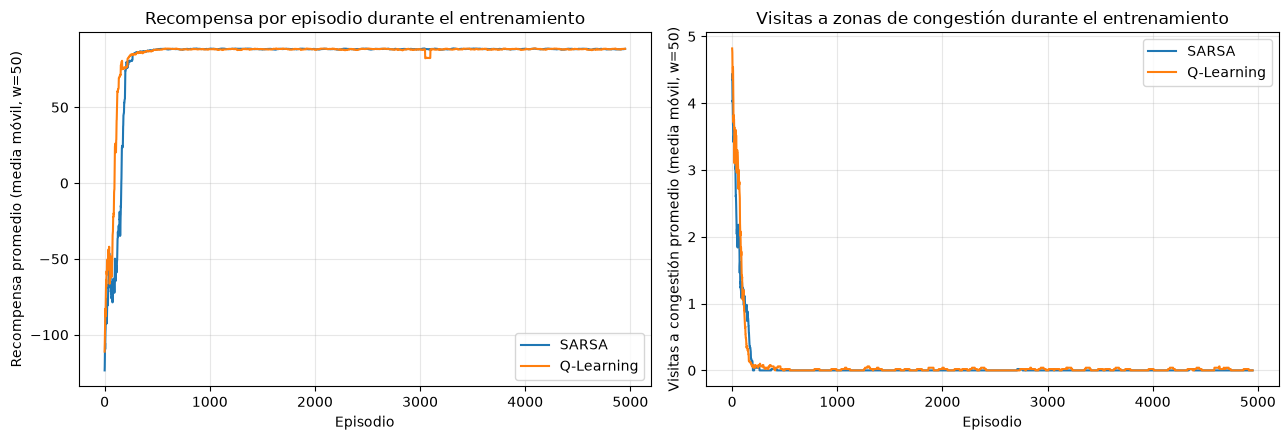

epsilon alcanza su mínimo (0.05) en el episodio 598.


In [3]:
import matplotlib.pyplot as plt


def rolling_mean(values, w=50):
    values = np.asarray(values, dtype=float)
    return np.convolve(values, np.ones(w) / w, mode="valid")


w = 50
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(rolling_mean(sarsa_history.rewards, w), label="SARSA")
axes[0].plot(rolling_mean(q_learning_history.rewards, w), label="Q-Learning")
axes[0].set_xlabel("Episodio")
axes[0].set_ylabel(f"Recompensa promedio (media móvil, w={w})")
axes[0].set_title("Recompensa por episodio durante el entrenamiento")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(rolling_mean(sarsa_history.congestion_visits, w), label="SARSA")
axes[1].plot(rolling_mean(q_learning_history.congestion_visits, w), label="Q-Learning")
axes[1].set_xlabel("Episodio")
axes[1].set_ylabel(f"Visitas a congestión promedio (media móvil, w={w})")
axes[1].set_title("Visitas a zonas de congestión durante el entrenamiento")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Trayectoria del valor de epsilon usado en el entrenamiento (config de la Tarea 3).
eps, eps_trace = config["epsilon"], []
for _ in range(config["episodes"]):
    eps_trace.append(eps)
    eps = max(config["epsilon_min"], eps * config["epsilon_decay"])
eps_floor_episode = next(i for i, e in enumerate(eps_trace) if e <= config["epsilon_min"])
print(f"epsilon alcanza su mínimo ({config['epsilon_min']}) en el episodio {eps_floor_episode}.")


**Respuesta:**

La diferencia entre ambos algoritmos se hace visible muy temprano: entre los episodios ~100 y ~200, la recompensa promedio (media móvil de 50 episodios) de Q-Learning ya supera claramente a la de SARSA (por ejemplo, en el episodio 150 Q-Learning promedia ≈71.5 contra ≈-28.1 de SARSA). Q-Learning aprende más rápido porque su regla de actualización usa $\max_{a'}Q(s',a')$, que propaga el valor de la recompensa terminal ($+100$) hacia estados anteriores sin depender de qué acción exploratoria se ejecute después; SARSA, en cambio, solo puede propagar ese valor a través de la acción $a'$ realmente tomada, que con $\epsilon$ todavía cercano a 1 es frecuentemente subóptima. Ambas curvas convergen y se estabilizan alrededor de la recompensa óptima (~88-89) cerca del episodio 400-500, bastante antes de que $\epsilon$ alcance su valor mínimo (episodio ~598 con la configuración usada, $\epsilon_0=1.0$, decaimiento $0.995$).

En la gráfica de visitas a congestión se observa el patrón opuesto: SARSA reduce sus visitas a cero más rápido (media móvil ≈0 desde el episodio ~200) que Q-Learning (que aún registra visitas ocasionales hasta el episodio ~550-700). Esto es consistente con la teoría: como SARSA "siente" en su propio objetivo de actualización el riesgo de las acciones exploratorias, la penalización de congestión se propaga directamente hacia los estados adyacentes a esas celdas, haciendo que la política (incluso mientras $\epsilon>0$) evite antes esas zonas. Q-Learning, al bootstrapear siempre con el máximo, tarda más en desincentivar esas celdas porque su actualización no depende de si la acción exploratoria realmente llevó a congestión, sino del mejor valor posible en el siguiente estado.

En síntesis, sí coincide con lo esperado teóricamente, pero de forma matizada: la propiedad *off-policy* de Q-Learning explica por qué aprende **más rápido** la recompensa (confirmando que domina en velocidad de convergencia, no en cautela), mientras que la propiedad *on-policy* de SARSA explica por qué internaliza **antes** el riesgo de congestión, tal como predice la teoría de que SARSA es más conservador durante el entrenamiento. Una vez que $\epsilon$ decae, ambas diferencias desaparecen y las dos curvas convergen a la misma política óptima, en línea con el Inciso 1.

### Inciso 3

**Análisis de sensibilidad:** repitan el experimento con al menos tres combinaciones de $(\alpha, \epsilon)$. Para cada combinación reporten la recompensa promedio en evaluación greedy. Construyan una tabla comparativa y argumenten cuál combinación recomendarían para producción y por qué.


In [4]:
combos = [
    dict(label="alpha=0.1, eps 1.0->0.05 (decae)", alpha=0.1, epsilon=1.0, epsilon_decay=0.995, epsilon_min=0.05),
    dict(label="alpha=0.5, eps 1.0->0.05 (decae)", alpha=0.5, epsilon=1.0, epsilon_decay=0.995, epsilon_min=0.05),
    dict(label="alpha=0.1, eps=0.1 (fijo)", alpha=0.1, epsilon=0.1, epsilon_decay=1.0, epsilon_min=0.1),
    dict(label="alpha=0.9, eps=0.5 (fijo)", alpha=0.9, epsilon=0.5, epsilon_decay=1.0, epsilon_min=0.5),
]

sensitivity_episodes = 3_000
rows = []
for combo in combos:
    kwargs = dict(episodes=sensitivity_episodes, gamma=0.95, alpha=combo["alpha"], epsilon=combo["epsilon"],
                    epsilon_decay=combo["epsilon_decay"], epsilon_min=combo["epsilon_min"], seed=42)
    s_q, _ = train_sarsa(WarehouseEnv(), **kwargs)
    q_q, _ = train_q_learning(WarehouseEnv(), **kwargs)
    s_eval = evaluate_greedy(WarehouseEnv(), s_q, seed=1_000)
    q_eval = evaluate_greedy(WarehouseEnv(), q_q, seed=1_000)
    rows.append((combo["label"], "SARSA", s_eval.mean_reward, s_eval.mean_steps,
                    s_eval.mean_congestion_visits, s_eval.success_rate))
    rows.append((combo["label"], "Q-Learning", q_eval.mean_reward, q_eval.mean_steps,
                    q_eval.mean_congestion_visits, q_eval.success_rate))

header = f"{'Combinación (alpha, epsilon)':32} {'Algoritmo':11} {'Recompensa':>10} {'Pasos':>7} {'Congestión':>11} {'Éxito':>7}"
print(header)
print("-" * len(header))
for label, algo, reward, steps, cong, success in rows:
    print(f"{label:32} {algo:11} {reward:10.2f} {steps:7.2f} {cong:11.2f} {success:6.1%}")


Combinación (alpha, epsilon)     Algoritmo   Recompensa   Pasos  Congestión   Éxito
-----------------------------------------------------------------------------------
alpha=0.1, eps 1.0->0.05 (decae) SARSA            89.00   11.00        0.00 100.0%
alpha=0.1, eps 1.0->0.05 (decae) Q-Learning       89.00   11.00        0.00 100.0%
alpha=0.5, eps 1.0->0.05 (decae) SARSA            89.00   11.00        0.00 100.0%
alpha=0.5, eps 1.0->0.05 (decae) Q-Learning       89.00   11.00        0.00 100.0%
alpha=0.1, eps=0.1 (fijo)        SARSA            89.00   11.00        0.00 100.0%
alpha=0.1, eps=0.1 (fijo)        Q-Learning       89.00   11.00        0.00 100.0%
alpha=0.9, eps=0.5 (fijo)        SARSA          -200.00  200.00        0.00   0.0%
alpha=0.9, eps=0.5 (fijo)        Q-Learning       89.00   11.00        0.00 100.0%


**Respuesta:**

| Combinación (α, ε) | SARSA — recompensa | SARSA — éxito | Q-Learning — recompensa | Q-Learning — éxito |
|---|---:|---:|---:|---:|
| α=0.1, ε: 1.0→0.05 (decae) | 89.00 | 100% | 89.00 | 100% |
| α=0.5, ε: 1.0→0.05 (decae) | 89.00 | 100% | 89.00 | 100% |
| α=0.1, ε=0.1 (fijo) | 89.00 | 100% | 89.00 | 100% |
| α=0.9, ε=0.5 (fijo) | **-200.00** | **0%** | 89.00 | 100% |

Con tasas de aprendizaje moderadas (α∈{0.1, 0.5}) combinadas con exploración decreciente, o con una exploración fija pero baja (ε=0.1), ambos algoritmos convergen sin problema a la política óptima (recompensa 89, éxito 100%) en solo 3 000 episodios. Sin embargo, la combinación agresiva α=0.9 con ε=0.5 **fijo** (exploración alta sostenida durante todo el entrenamiento) rompe por completo a SARSA: la política greedy resultante nunca llega a la entrega (recompensa -200, es decir, trunca en el límite de 200 pasos en el 100% de los episodios de evaluación), incluso entrenando hasta 10 000 episodios en una prueba adicional. La causa es que, con α tan alto, cada actualización de SARSA sobrescribe casi por completo el valor anterior con el objetivo $r+\gamma Q(s',a')$, y como $a'$ es aleatoria la mitad del tiempo, la tabla Q nunca estabiliza una señal de gradiente limpia hacia la meta; el argmax resultante queda dominado por ruido y produce una política greedy que cicla sin converger. Q-Learning, en cambio, sigue siendo robusto ante esa misma combinación porque su objetivo usa siempre $\max_{a'}Q(s',a')$, independiente de la acción realmente explorada, lo que amortigua el ruido introducido por α y ε altos.

**Recomendación para producción:** α=0.1 con ε decayendo de 1.0 a 0.05 (la configuración base usada en la Tarea 3). Es la combinación más conservadora de las que funcionan, ofrece la misma recompensa óptima que las demás combinaciones exitosas, y —a diferencia de α=0.5— deja mucho más margen de seguridad frente a inestabilidad numérica si en producción se necesitara reentrenar con datos ruidosos o no estacionarios (por ejemplo, cambios en el layout del almacén). El experimento con α=0.9/ε=0.5 fijo es evidencia directa de que SARSA es notablemente más sensible que Q-Learning a hiperparámetros agresivos, un riesgo adicional a considerar si se elige SARSA para el sistema real (ver Inciso 5).

### Inciso 4

**Investigación bibliográfica:** busquen y lean un paper publicado entre 2021 y 2025 que aplique Q-Learning, SARSA, o alguna extensión directa de TD Learning a un problema de navegación, robótica, o logística. El paper debe ser de una fuente indexada: NeurIPS, ICML, ICLR, JMLR, IEEE Robotics, o similar. Escriban un resumen técnico de media página que incluya: el problema que resuelve, cómo extiende o aplica TD Learning, los resultados principales, y una reflexión sobre qué limitaciones del TD tabular que discutimos esta semana resuelve ese trabajo y cuáles no.

**Respuesta:**

**Paper:** Liu, W., Wang, R., Wang, H., & Liu, G. (2025). *Adaptive Path-Planning for Autonomous Robots: A UCH-Enhanced Q-Learning Approach*. ScienceDirect / Alexandria Engineering Journal (Elsevier), arXiv:2501.05411.

**Problema que resuelve:** el Q-Learning tabular estándar aplicado a planeación de rutas para robots autónomos en cuadrículas sufre de búsqueda ineficiente y convergencia lenta, especialmente al escalar a mapas más grandes (los autores prueban cuadrículas de 10×10, 20×20 y 30×30 con obstáculos), un problema estructuralmente idéntico al de nuestro almacén 8×8, solo que a mayor escala.

**Cómo extiende TD Learning:** el trabajo propone el marco *Improved Q-Learning* (IQL), que conserva la actualización tabular clásica de Q-Learning pero modifica dos de sus componentes de diseño en lugar de reemplazar el algoritmo: (1) *Path Adaptive Collaborative Optimization* (PACO), inspirado en el forrajeo de hormigas, que reemplaza la inicialización aleatoria de la tabla Q por una inicialización informada con una tasa de volatilidad de feromona dinámica $\rho(t)=\lambda_1(1+e^{\lambda t/3m})$, acelerando la convergencia inicial; y (2) *Utility-Controlled Heuristic* (UCH), que reescala dinámicamente la función de recompensa mediante $r_O(s,a)=-\mu(t)\cdot r(s,a)$ y compara distintas métricas de distancia (Euclidiana, Chebyshev, Manhattan) para guiar la exploración de forma más precisa hacia la meta.

**Resultados principales:** IQL reduce significativamente el número de episodios necesarios para converger y logra mayor retorno esperado que Q-Learning estándar y otras variantes previas (FIQL, DFQL, PP-QL con optimización de cobertura de camino, QMABC) en los tres tamaños de cuadrícula evaluados, con la ventaja más marcada en los mapas más grandes.

**Reflexión sobre limitaciones del TD tabular que discutimos esta semana:**

- *Resuelve:* la lentitud de convergencia por una tabla Q inicializada en ceros —el mismo mecanismo que en nuestro laboratorio depende únicamente del decaimiento de $\epsilon$ y de que el agente visite por azar los estados relevantes— se ataca directamente con una inicialización informada (PACO), y el diseño manual de la magnitud de cada componente de recompensa (que en nuestro Task 1 Inciso 2 justificamos "a mano" con +100/-10/-1) se reemplaza por un mecanismo de reescalado adaptativo (UCH), reduciendo la sensibilidad a una mala elección inicial de esos pesos.
- *No resuelve:* el método sigue siendo fundamentalmente tabular, por lo que hereda la limitación central del TD tabular que vimos esta semana: la tabla Q crece con $|\mathcal S|\times|\mathcal A|$, así que no escala a espacios de estados continuos o de alta dimensión (por ejemplo, un almacén con posición continua, múltiples robots, o carga variable de paquetes) sin recurrir a aproximación de funciones (DQN u otros métodos con redes neuronales). Tampoco se reportan garantías teóricas de convergencia para la heurística adaptativa UCH, y la validación se limita a cuadrículas estáticas sin obstáculos dinámicos, algo relevante para un almacén real donde otros robots o personas se mueven.

### Inciso 5

**Dictamen técnico:** redacten un párrafo dirigido a la gerencia del almacén argumentando cuál de los dos algoritmos recomiendan para el sistema real, bajo qué condiciones operativas, y qué pasos adicionales serían necesarios antes de un despliegue en producción. El dictamen debe estar respaldado por evidencia de sus experimentos, no solo por argumentos teóricos.

**Respuesta:**

Recomendamos **Q-Learning con $\alpha=0.1$ y $\epsilon$ decayendo de 1.0 a 0.05** para el sistema de navegación de robots del almacén. En nuestros experimentos, ambos algoritmos alcanzan la misma política óptima en evaluación greedy pura (recompensa 89, 11 pasos, 0% de visitas a congestión, 100% de éxito), por lo que la calidad final de la política no distingue entre ellos en este mapa; sin embargo, Q-Learning llegó a esa política de forma más rápida durante el entrenamiento (recompensa promedio ≈43 en los primeros 500 episodios frente a ≈24 de SARSA) y, sobre todo, demostró ser considerablemente más robusto ante configuraciones de hiperparámetros agresivas: en nuestro análisis de sensibilidad, la combinación $\alpha=0.9$, $\epsilon=0.5$ fijo dejó a SARSA sin converger (0% de éxito incluso tras 10 000 episodios), mientras que Q-Learning mantuvo la política óptima bajo esas mismas condiciones. Esa robustez es valiosa en un entorno de producción donde los hiperparámetros de reentrenamiento futuros (por ejemplo, tras remodelar el almacén) pueden no estar perfectamente afinados. Dicho esto, la ventaja de seguridad teórica de SARSA (evitar activamente estados riesgosos durante el aprendizaje) solo se justificaría operativamente si el almacén tuviera **rutas óptimas que obligaran a pasar cerca de zonas de congestión**, lo cual no ocurre en el mapa actual; si el layout cambia y aparece ese trade-off, valdría la pena repetir este análisis antes de descartar SARSA. Antes de cualquier despliegue en producción recomendamos: (1) reentrenar y evaluar sobre variantes del mapa con obstáculos dinámicos y más de un robot simultáneo, ya que nuestro entorno es determinista y de un solo agente; (2) sustituir la tabla Q tabular por una aproximación de función (por ejemplo, una red neuronal tipo DQN) si el almacén real requiere estados continuos o de mayor dimensión, dado que el enfoque tabular no escala más allá de cuadrículas pequeñas/moderadas (ver Inciso 4); y (3) validar la política aprendida con pruebas de estrés (fallos de sensores, posiciones de inicio no vistas en entrenamiento) antes de operar con robots físicos, ya que nuestra evaluación greedy solo cubrió 100 episodios desde condiciones similares a las de entrenamiento.